In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
df_train = pd.read_csv("train.csv",encoding = "latin1")
df_test = pd.read_csv("test.csv",encoding = "latin1")

In [15]:
df_train.head()
df_test.tail()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
269995,899995,21,other,b.com,2.55,82.3,yes,8.4,average,mixed,medium,hard
269996,899996,17,female,b.com,0.49,46.4,yes,8.8,good,mixed,low,easy
269997,899997,22,male,bba,6.62,74.7,yes,5.5,good,coaching,high,easy
269998,899998,22,other,ba,4.08,51.8,yes,8.7,poor,online videos,high,moderate
269999,899999,20,female,b.com,5.86,59.7,yes,8.9,poor,mixed,medium,moderate


In [4]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [5]:
df_train.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [6]:
df_train.isnull().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

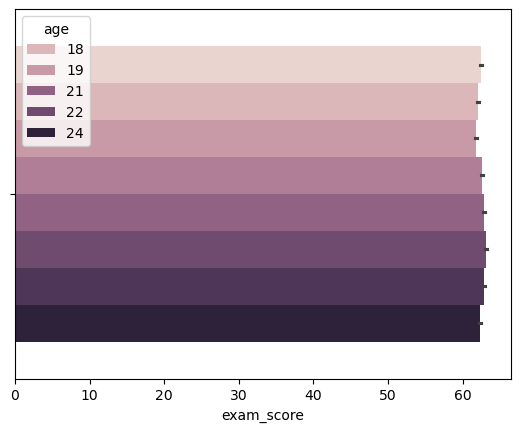

In [13]:
sns.barplot( x = "exam_score" , hue = "age" , data=df_train)
plt.show()

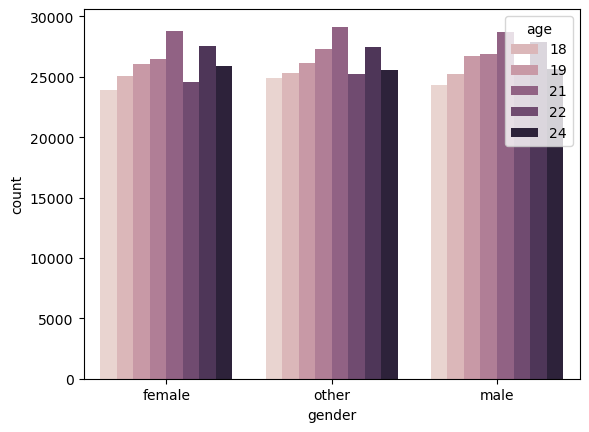

In [14]:
sns.countplot( x = "gender" , hue = "age" , data=df_train)
plt.show()

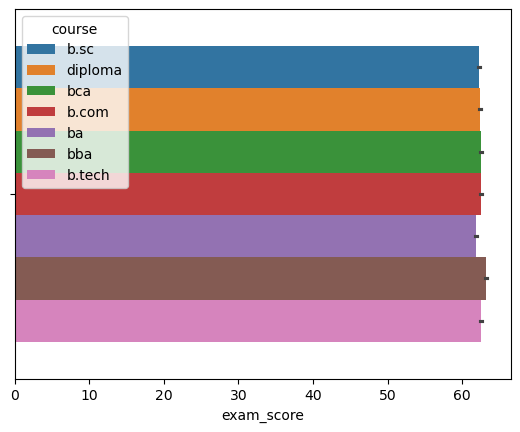

In [16]:
sns.barplot( x = "exam_score" , hue = "course" , data=df_train)
plt.show()

In [29]:
X = df_train.drop("exam_score",axis=1)
y = df_train["exam_score"]

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorial_data = ["gender","course","internet_access","sleep_quality","study_method","facility_rating","exam_difficulty"]
numerical_data = ["id","age","study_hours","class_attendance","sleep_hours"]

preprocessor = ColumnTransformer(
               transformers = [
                ("cat",OneHotEncoder(),categorial_data),
                ("num",StandardScaler(),numerical_data)
               ]
)
preprocessor


ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                 ['gender', 'course', 'internet_access',
                                  'sleep_quality', 'study_method',
                                  'facility_rating', 'exam_difficulty']),
                                ('num', StandardScaler(),
                                 ['id', 'age', 'study_hours',
                                  'class_attendance', 'sleep_hours'])])

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression   

model = Pipeline(
        steps = [
            ("preprocessor",preprocessor),
            ("classifier", LinearRegression())
        ]
)
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['gender', 'course',
                                                   'internet_access',
                                                   'sleep_quality',
                                                   'study_method',
                                                   'facility_rating',
                                                   'exam_difficulty']),
                                                 ('num', StandardScaler(),
                                                  ['id', 'age', 'study_hours',
                                                   'class_attendance',
                                                   'sleep_hours'])])),
                ('classifier', LinearRegression())])

In [35]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['gender', 'course',
                                                   'internet_access',
                                                   'sleep_quality',
                                                   'study_method',
                                                   'facility_rating',
                                                   'exam_difficulty']),
                                                 ('num', StandardScaler(),
                                                  ['id', 'age', 'study_hours',
                                                   'class_attendance',
                                                   'sleep_hours'])])),
                ('classifier', LinearRegression())])

In [40]:
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score  
r2 =r2_score(y_test,y_pred)

print(" r2_score = ",  r2)

 r2_score =  0.7785040290365254


In [41]:
model.fit(X,y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['gender', 'course',
                                                   'internet_access',
                                                   'sleep_quality',
                                                   'study_method',
                                                   'facility_rating',
                                                   'exam_difficulty']),
                                                 ('num', StandardScaler(),
                                                  ['id', 'age', 'study_hours',
                                                   'class_attendance',
                                                   'sleep_hours'])])),
                ('classifier', LinearRegression())])

In [42]:
test_pred = model.predict(df_test)

In [43]:
submission = pd.DataFrame({
    "Id": df_test["id"],
    "exam_score ": test_pred
})

In [44]:
submission.to_csv("sample_submission.csv", index=False)

In [45]:
import pickle
with open("test_score.pkl", "wb") as file:
    pickle.dump(model, file)
